In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_excel('Credit_Analysis_Dataset.xlsx', sheet_name='Sheet1', engine='openpyxl')

# Initial inspection
print("First 5 rows:")
print(df.head())
print("\nData info:")
print(df.info())
print("\nSummary statistics (Numerical):")
print(df.describe())
print("\nSummary statistics (Categorical):")
print(df.describe(include=['O']))

c:\Users\USER\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


First 5 rows:
   Unnamed: 0 default student      balance        income
0           1      No      No   729.526495  44361.625074
1           2      No     Yes   817.180407  12106.134700
2           3      No      No  1073.549164  31767.138947
3           4      No      No   529.250605  35704.493935
4           5      No      No   785.655883  38463.495879

Data info:
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  10000 non-null  int64  
 1   default     10000 non-null  str    
 2   student     10000 non-null  str    
 3   balance     10000 non-null  float64
 4   income      10000 non-null  float64
dtypes: float64(2), int64(1), str(2)
memory usage: 433.0 KB
None

Summary statistics (Numerical):
        Unnamed: 0       balance        income
count  10000.00000  10000.000000  10000.000000
mean    5000.50000    835.374886  33516.981876
std     28

C:\Users\USER\AppData\Local\Temp\ipykernel_28772\3883602121.py:16: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.describe(include=['O']))


C:\Users\USER\AppData\Local\Temp\ipykernel_28772\191367370.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='default', y='balance', data=df_clean, ax=axes[0], palette='Set2')
C:\Users\USER\AppData\Local\Temp\ipykernel_28772\191367370.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='default', y='income', data=df_clean, ax=axes[1], palette='Set2')


Correlation Matrix:
                  balance    income  default_binary  student_binary
balance         1.000000 -0.152243        0.350119        0.203578
income         -0.152243  1.000000       -0.019871       -0.753985
default_binary  0.350119 -0.019871        1.000000        0.035420
student_binary  0.203578 -0.753985        0.035420        1.000000

Summary statistics by Default Status:
             balance                                 income                \
               mean       median         std          mean        median   
default                                                                    
No        803.94375   802.857102  456.476236  33566.166625  34589.488060   
Yes      1747.82169  1789.093391  341.266808  32089.147124  31515.344493   

                       
                  std  
default                
No       13318.251249  
Yes      13804.221110  

Summary statistics by Student Status:
             balance                                income      

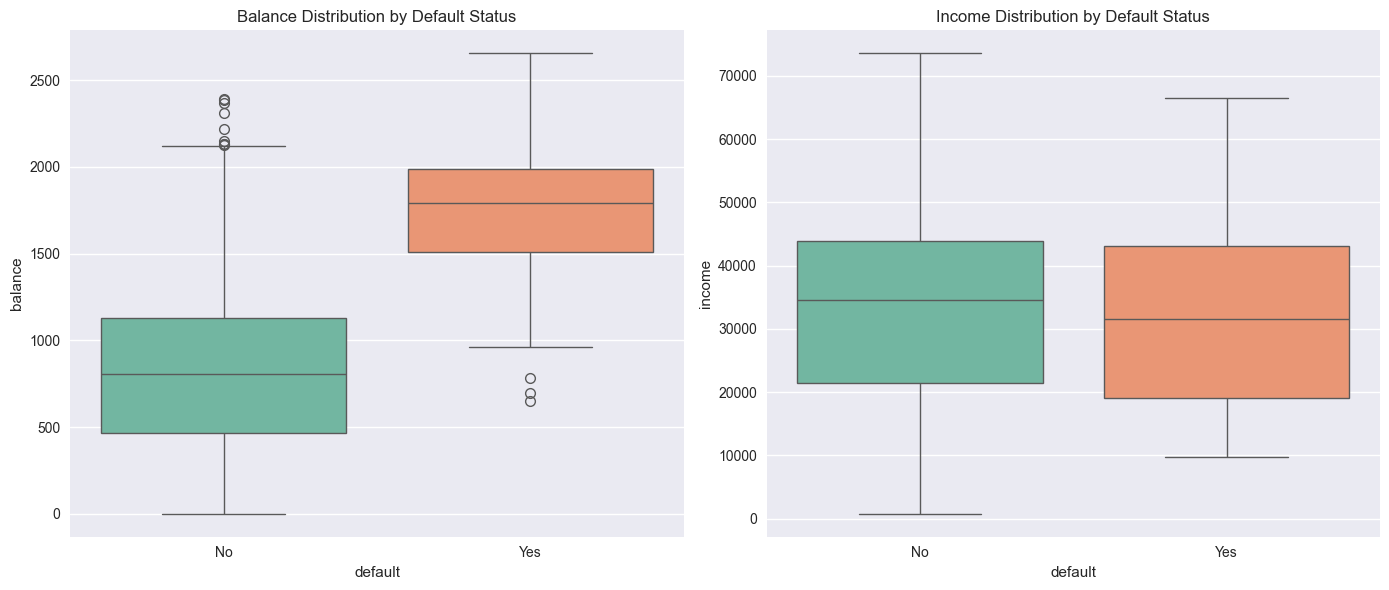

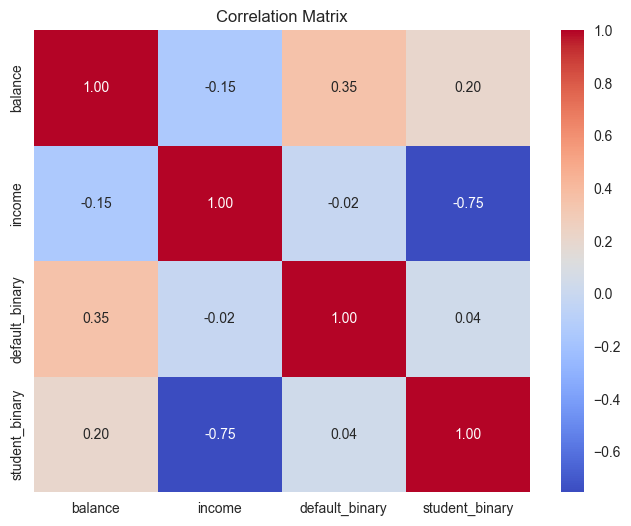

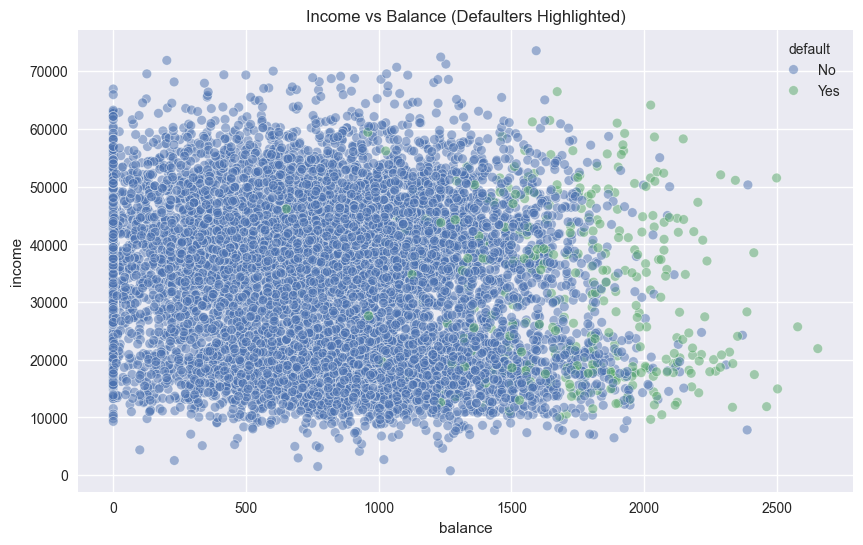

In [6]:
import numpy as np

# 1. Cleaning: Drop the index column
df_clean = df.drop(columns=['Unnamed: 0'])

# 2. Encoding categorical variables for correlation
df_clean['default_binary'] = df_clean['default'].map({'Yes': 1, 'No': 0})
df_clean['student_binary'] = df_clean['student'].map({'Yes': 1, 'No': 0})

# 3. Correlation matrix
corr_matrix = df_clean[['balance', 'income', 'default_binary', 'student_binary']].corr()

# 4. Statistical Summary by 'default'
summary_by_default = df_clean.groupby('default')[['balance', 'income']].agg(['mean', 'median', 'std'])

# 5. Statistical Summary by 'student'
summary_by_student = df_clean.groupby('student')[['balance', 'income']].agg(['mean', 'median', 'std'])

# 6. Visualizations
plt.style.use('seaborn-v0_8')

# A. Distribution of Balance and Income by Default Status
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(x='default', y='balance', data=df_clean, ax=axes[0], palette='Set2')
axes[0].set_title('Balance Distribution by Default Status')

sns.boxplot(x='default', y='income', data=df_clean, ax=axes[1], palette='Set2')
axes[1].set_title('Income Distribution by Default Status')

plt.tight_layout()
plt.savefig('distribution_by_default.png')

# B. Correlation Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.savefig('correlation_heatmap.png')

# C. Balance vs Income colored by Student and Default
plt.figure(figsize=(10, 6))
sns.scatterplot(x='balance', y='income', hue='default', alpha=0.5, data=df_clean)
plt.title('Income vs Balance (Defaulters Highlighted)')
plt.savefig('scatter_income_balance.png')

print("Correlation Matrix:\n", corr_matrix)
print("\nSummary statistics by Default Status:\n", summary_by_default)
print("\nSummary statistics by Student Status:\n", summary_by_student)